# WS04 — Devnagari Digit Classification with Fully Connected Network
### 6CS012 · Complete Solution (Copy & Paste into Google Colab)

---
## Step 0 · Mount Google Drive & Extract Dataset

In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# import zipfile, os

# # ── CHANGE THIS to the path of your zip file in Google Drive ──────────────────
# zip_path   = '/content/drive/MyDrive/Ai and Machine Learning/DevanagariHandwrittenDigitDataset'
# extract_to = os.path.dirname(zip_path)   # extract into the SAME folder as the zip

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_to)

# print("Extracted to:", extract_to)

# # Show what was extracted
# for item in os.listdir(extract_to):
#     print(" -", item)


---
## Task 1 · Data Preparation — Load, Preprocess & Visualise

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from PIL import Image

# ── CHANGE THESE paths to match where your dataset was extracted ───────────────
train_dir = '/content/drive/MyDrive/Ai and Machine Learning/DevanagariHandwrittenDigitDataset/Train'
test_dir  = '/content/drive/MyDrive/Ai and Machine Learning/DevanagariHandwrittenDigitDataset/Test'

# Image size (Devnagari digits are resized to 28x28)
IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES = 10

# ─────────────────────────────────────────────────────────────────────────────
def load_images_from_folder(folder):
    """
    Loads all images from a folder that has this structure:
        folder/
            digit_0/  ← images of digit 0
            digit_1/  ← images of digit 1
            ...
            digit_9/  ← images of digit 9

    Returns:
        images : numpy array of shape (N, 28, 28)
        labels : numpy array of shape (N,)  — integer class index
    """
    images      = []
    labels      = []
    class_names = sorted(os.listdir(folder))               # ['digit_0', 'digit_1', ...]
    class_map   = {name: i for i, name in enumerate(class_names)}  # name → int label

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue                                        # skip stray files
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")            # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))          # 28 × 28
                img = np.array(img) / 255.0                        # normalise [0,1]
                images.append(img)
                labels.append(label)
            except Exception:
                pass                                       # skip unreadable files

    return np.array(images), np.array(labels)

# ── Load ──────────────────────────────────────────────────────────────────────
print("Loading training data ...")
x_train_raw, y_train_raw = load_images_from_folder(train_dir)

print("Loading test data ...")
x_test_raw,  y_test_raw  = load_images_from_folder(test_dir)

print(f"\nRaw training set : {x_train_raw.shape}  labels: {y_train_raw.shape}")
print(f"Raw test set      : {x_test_raw.shape}   labels: {y_test_raw.shape}")


Loading training data ...
Loading test data ...

Raw training set : (17000, 28, 28)  labels: (17000,)
Raw test set      : (3000, 28, 28)   labels: (3000,)


In [8]:
# ── Reshape for Keras  (N, 28, 28) → (N, 784)  flat vector ───────────────────
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)   # (N, 784)
x_test  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)   # (N, 784)

# ── One-hot encode labels  e.g. 3 → [0,0,0,1,0,0,0,0,0,0] ───────────────────
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"x_train shape : {x_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"x_test  shape : {x_test.shape}")
print(f"y_test  shape : {y_test.shape}")


x_train shape : (17000, 784)
y_train shape : (17000, 10)
x_test  shape : (3000, 784)
y_test  shape : (3000, 10)


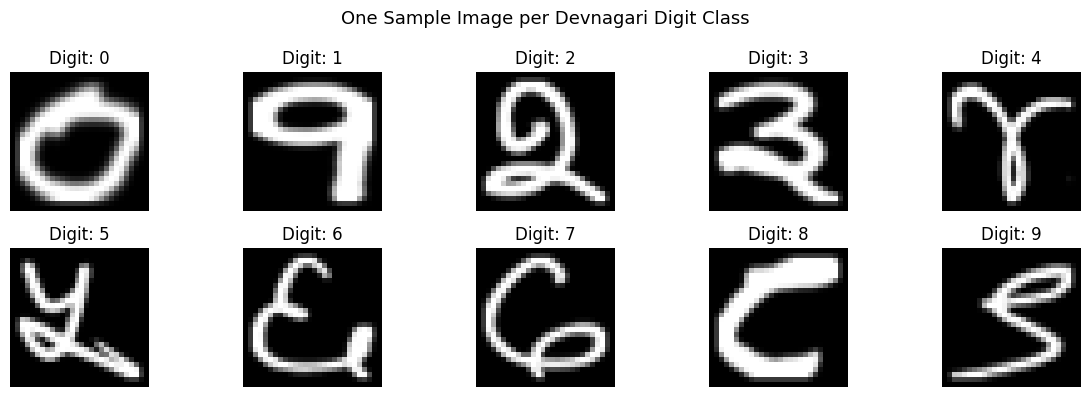

In [9]:
# ── Visualise one sample image per class ─────────────────────────────────────
plt.figure(figsize=(12, 4))
for digit in range(NUM_CLASSES):
    idx   = np.where(y_train_raw == digit)[0][0]   # first image of this class
    image = x_train_raw[idx]                        # still (28,28)
    plt.subplot(2, 5, digit + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Digit: {digit}")
    plt.axis("off")
plt.suptitle("One Sample Image per Devnagari Digit Class", fontsize=13)
plt.tight_layout()
plt.show()


---
## Task 2 · Build the FCN Model (Sequential API)

In [10]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

# ── Model Architecture ────────────────────────────────────────────────────────
#   Input  : 784 pixel values (flattened 28×28 grayscale image)
#   Layer 1: Dense  64 neurons, sigmoid activation
#   Layer 2: Dense 128 neurons, sigmoid activation
#   Layer 3: Dense 256 neurons, sigmoid activation
#   Output : Dense  10 neurons, softmax  (one per Devnagari digit class)
# ─────────────────────────────────────────────────────────────────────────────

model = Sequential([
    Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),         # 784 input features

    Dense(64,  activation='sigmoid'),               # Hidden layer 1
    Dense(128, activation='sigmoid'),               # Hidden layer 2
    Dense(256, activation='sigmoid'),               # Hidden layer 3

    Dense(NUM_CLASSES, activation='softmax'),       # Output layer (10 classes)
])

# Print a summary of all layers and parameter counts
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3 · Compile the Model

In [11]:
# Optimizer : Adam  — general purpose, works well for image classification
# Loss      : categorical_crossentropy — because labels are one-hot encoded
# Metric    : accuracy — to monitor classification performance
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully!")


Model compiled successfully!


---
## Task 4 · Train the Model

In [14]:
# ── Save path for best model checkpoint ──────────────────────────────────────
checkpoint_path = '/content/drive/MyDrive/Ai and Machine Learning/DevanagariHandwrittenDigitDataset/best_model.keras'

callbacks = [
    # Saves the model whenever validation accuracy improves
    keras.callbacks.ModelCheckpoint(
        filepath   = checkpoint_path,
        monitor    = 'val_accuracy',
        save_best_only = True,
        verbose    = 1
    ),
    # Stops training early if val_loss does not improve for 5 epochs
    keras.callbacks.EarlyStopping(
        monitor  = 'val_loss',
        patience = 5,
        verbose  = 1,
        restore_best_weights = True
    ),
]

# ── Train ─────────────────────────────────────────────────────────────────────
BATCH_SIZE = 128
EPOCHS     = 20

history = model.fit(
    x_train, y_train,
    batch_size       = BATCH_SIZE,
    epochs           = EPOCHS,
    validation_split = 0.2,      # 20% of training data used for validation
    callbacks        = callbacks,
    verbose          = 1
)


Epoch 1/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2598 - loss: 2.0244
Epoch 1: val_accuracy improved from None to 0.00000, saving model to /content/drive/MyDrive/Ai and Machine Learning/DevanagariHandwrittenDigitDataset/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Ai and Machine Learning/DevanagariHandwrittenDigitDataset/best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4576 - loss: 1.6670 - val_accuracy: 0.0000e+00 - val_loss: 7.4587
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7809 - loss: 0.6901
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8143 - loss: 0.5517 - val_accuracy: 0.0000e+00 - val_loss: 8.8573
Epoch 3/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8694 - loss: 0.3401
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8881 - loss: 0.3141 - val_accuracy: 0.0000e

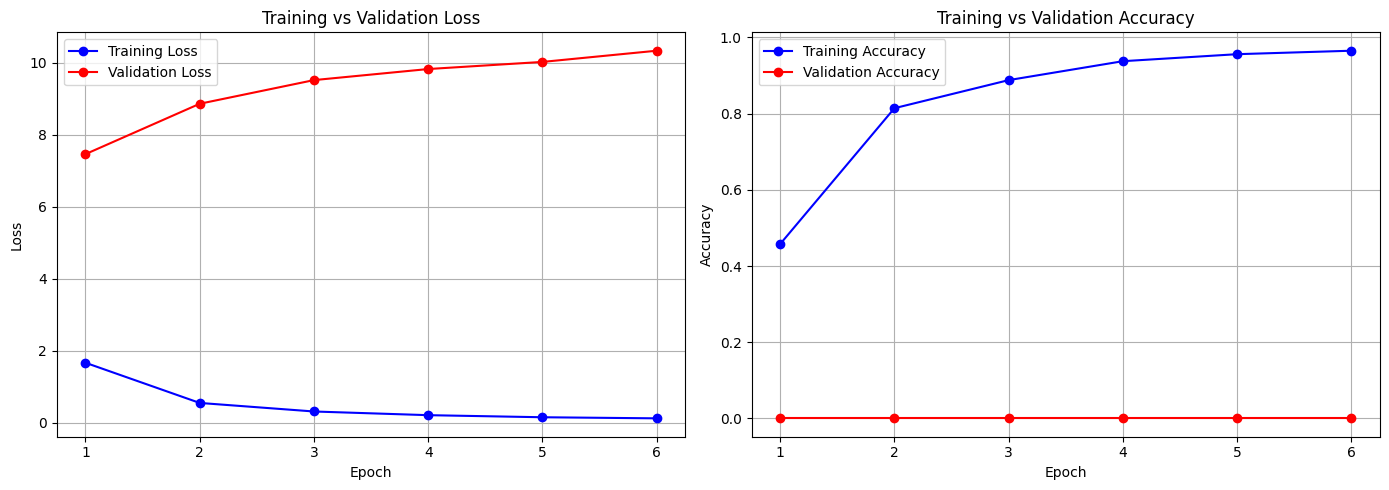

In [15]:
# ── Plot Training History ─────────────────────────────────────────────────────
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs_ran, val_loss,   'r-o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_acc, 'b-o', label='Training Accuracy')
plt.plot(epochs_ran, val_acc,   'r-o', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


---
## Task 5 · Evaluate the Model on Test Set

In [ ]:
# Evaluate on the held-out test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*40}")


---
## Task 6 · Save and Load the Model

In [16]:
# ── Save the trained model as .h5 file ───────────────────────────────────────
save_path = '/content/drive/MyDrive/Ai and Machine Learning/DevanagariHandwrittenDigitDataset/devnagari_fcn_model.h5'
model.save(save_path)
print(f"Model saved to: {save_path}")


Model saved to: /content/drive/MyDrive/Ai and Machine Learning/DevanagariHandwrittenDigitDataset/devnagari_fcn_model.h5


In [17]:
# ── Load the model back ───────────────────────────────────────────────────────
loaded_model = tf.keras.models.load_model(save_path)
print("Model loaded successfully!")

# Re-evaluate the loaded model to confirm it works identically
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded Model — Test Loss: {loaded_loss:.4f}  |  Test Accuracy: {loaded_acc:.4f}")


Model loaded successfully!
94/94 - 1s - 8ms/step - accuracy: 0.5807 - loss: 2.1962

Loaded Model — Test Loss: 2.1962  |  Test Accuracy: 0.5807


---
## Task 7 · Make Predictions & Visualise Results

In [18]:
# ── Run predictions on the entire test set ────────────────────────────────────
predictions      = model.predict(x_test)               # shape: (N, 10) — probabilities
predicted_labels = np.argmax(predictions, axis=1)      # convert to class index
true_labels      = np.argmax(y_test,      axis=1)      # true class index

# Quick check: first 5 predictions vs true labels
print("Sample Predictions vs True Labels:")
print(f"{'Image':<8} {'Predicted':>10} {'True':>6} {'Correct?':>10}")
print("-" * 38)
for i in range(5):
    correct = "✅" if predicted_labels[i] == true_labels[i] else "❌"
    print(f"{i:<8} {predicted_labels[i]:>10} {true_labels[i]:>6} {correct:>10}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Sample Predictions vs True Labels:
Image     Predicted   True   Correct?
--------------------------------------
0                 0      0          ✅
1                 0      0          ✅
2                 0      0          ✅
3                 0      0          ✅
4                 0      0          ✅


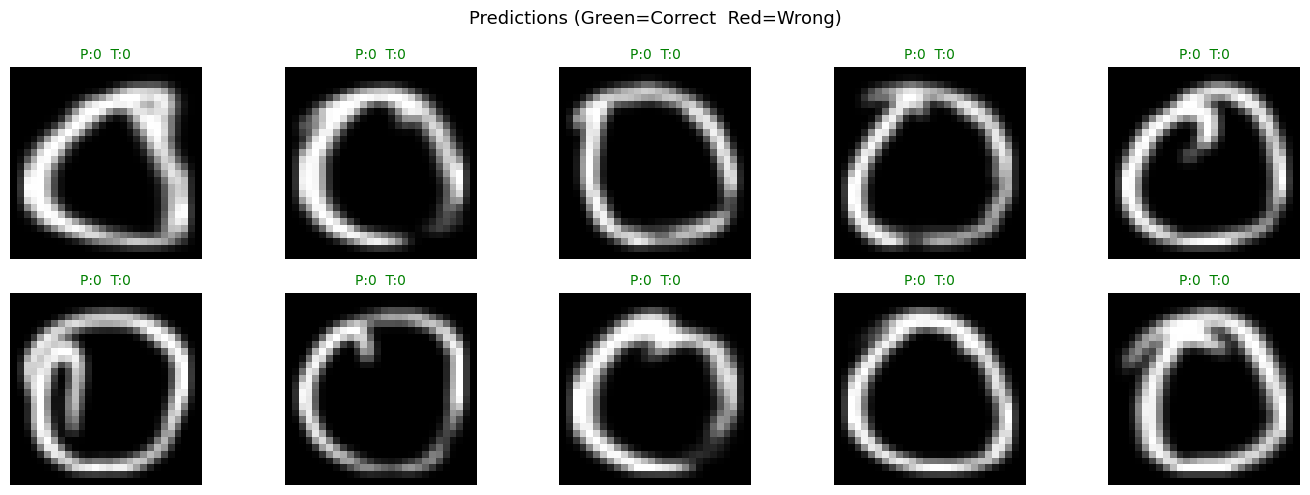

In [19]:
# ── Visualise 10 test images with Predicted vs True labels ───────────────────
plt.figure(figsize=(14, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')

    pred  = predicted_labels[i]
    true  = true_labels[i]
    color = 'green' if pred == true else 'red'

    plt.title(f"P:{pred}  T:{true}", color=color, fontsize=10)
    plt.axis("off")

plt.suptitle("Predictions (Green=Correct  Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()


In [20]:
# ── Overall accuracy summary ──────────────────────────────────────────────────
overall_acc = np.mean(predicted_labels == true_labels)
print(f"Overall Prediction Accuracy on Test Set: {overall_acc*100:.2f}%")


Overall Prediction Accuracy on Test Set: 58.07%
